# Import các class

In [1]:
import csv
from utils.data_handler import DataHandler
from utils.ml_models import SentimentModel
from utils.visualizer import ModelVisualizer

# Xử lý lại dạng txt ra csv để có thể mở bằng excel dễ nhìn, dễ tái sử dụng

In [2]:
input_txt = 'train.txt'  
output_csv = 'result.csv'

with open(input_txt, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]
lines=lines[1:]

with open(output_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
    f.write("STT,class,text\n")    
    for i, line in enumerate(lines):
        parts = line.split(',', 2) 
        if len(parts) == 3:
            STT=parts[0]
            label = parts[1]
            content = parts[2]
            writer.writerow([STT, label, content])

print(f"Đã lưu file {output_csv} xong!")

Đã lưu file result.csv xong!


# Chia data train/test

In [3]:

data = DataHandler('result.csv')
X_train, X_test, y_train, y_test = data.load_and_split()
X_train_vec, X_test_vec = data.vectorize_data(X_train, X_test)

trainer = SentimentModel()

# Chạy thử Logistic Regression

Saved 'Logistic Regression' at 'logistic_model.pkl'
Accuracy: 0.8490



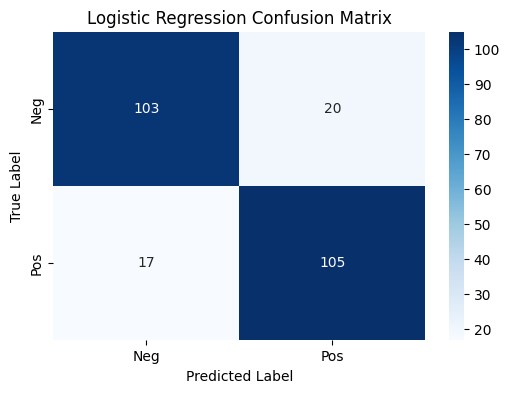

In [4]:
model_lr, y_pred_lr, acc_lr, report_lr = trainer.train_and_evaluate(
    model_name='Logistic Regression',
    X_train_vec=X_train_vec, 
    y_train=y_train, 
    X_test_vec=X_test_vec, 
    y_test=y_test,
    vectorizer=data.vectorizer,  # Phải truyền vectorizer vào để save
    save_model=True,             # Lựa chọn bật/tắt việc lưu file
    filepath="logistic_model.pkl"
)
print(f"Accuracy: {acc_lr:.4f}\n")

ModelVisualizer.plot_confusion_matrix(y_test, y_pred_lr, title="Logistic Regression Confusion Matrix")

In [5]:
pred, prob = SentimentModel.predict_single_text("This car is absolutely beautiful and runs smoothly!", "logistic_model.pkl")
print(f"Inference kết quả: {pred} | Xác suất: {prob}\n")

Inference kết quả: Pos | Xác suất: {'Neg': np.float64(0.3994156982753697), 'Pos': np.float64(0.6005843017246303)}



# Chạy thử SVM

Accuracy: 0.8327



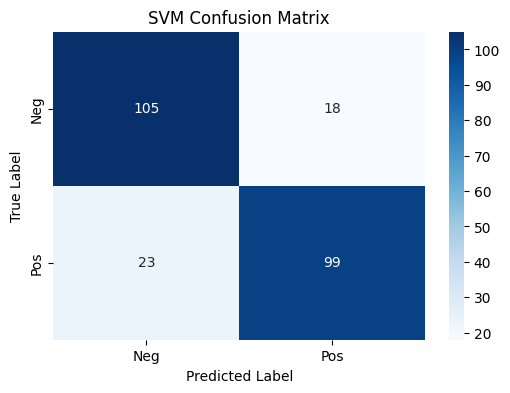

In [6]:
model_svm, y_pred_svm, acc_svm, report_svm = trainer.train_and_evaluate(
    model_name='SVM',
    X_train_vec=X_train_vec, 
    y_train=y_train, 
    X_test_vec=X_test_vec, 
    y_test=y_test,
)
print(f"Accuracy: {acc_svm:.4f}\n")

ModelVisualizer.plot_confusion_matrix(y_test, y_pred_svm, title="SVM Confusion Matrix")

# Nếu sau này muốn update thuật toán thì chỉ cần import rồi tạo dictionary thì class sẽ có thêm các thuật toán ML mới (naive bayes không có sẵn trong class ml_models.py)

Processing algorithm: Model LogReg...
Processing algorithm: Model SVM...
Processing algorithm: Model Naive Bayes...


,Model,Accuracy
0,Model LogReg,0.848980
1,Model Naive Bayes,0.836735
2,Model SVM,0.832653


c:\Project\ML-LLM\utils\visualizer.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


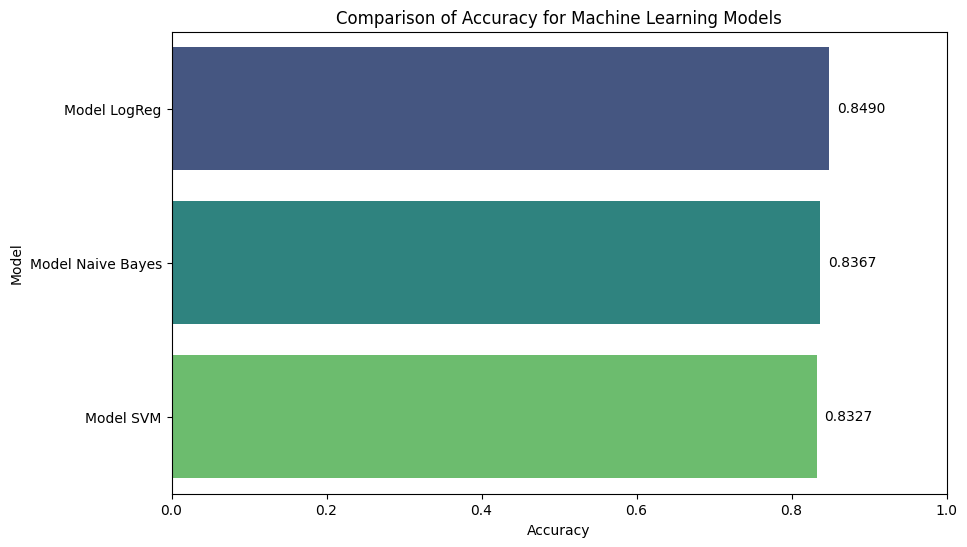

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from utils.ml_models import ModelComparator

# Initialize a dictionary containing the algorithms to "compete"
my_models = {
    'Model LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'Model SVM': LinearSVC(max_iter=1000, random_state=42),
    'Model Naive Bayes': MultinomialNB() 
}

comparator = ModelComparator(models_to_compare=my_models)
df_compare = comparator.compare(X_train_vec, y_train, X_test_vec, y_test)

display(df_compare)
ModelVisualizer.plot_model_comparison(df_compare)

# Thử dùng LLM

In [ ]:
from utils.llm_models import LLMSentimentAnalyzer

# Khởi tạo model
llm_analyzer = LLMSentimentAnalyzer(model_name="llama3.2:3b")

test_sentence = "The transmission is clunky, but overall the seats are comfortable. Not sure if I would buy it again."

print("Zero-shot prediction:", llm_analyzer.predict_zero_shot(test_sentence))
print("Few-shot prediction:", llm_analyzer.predict_few_shot(test_sentence))


# Evaluate Zero-shot
y_pred_zero, acc_zero, report_zero = llm_analyzer.evaluate_dataset(
    X_test,
    y_test,
    strategy="zero_shot",
    batch_size=8
)

print(f"\nAccuracy LLM Zero-shot: {acc_zero:.4f}")
print(report_zero)


# Evaluate Few-shot
y_pred_few, acc_few, report_few = llm_analyzer.evaluate_dataset(
    X_test,
    y_test,
    strategy="few_shot",
    batch_size=8
)

print(f"\nAccuracy LLM Few-shot: {acc_few:.4f}")
print(report_few)

Đang khởi tạo kết nối với Ollama model: llama3.2:3b...


c:\Project\ML-LLM\utils\llm_models.py:16: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  self.llm = Ollama(


Zero-shot prediction: Neg
Few-shot prediction: Neg
Đang chạy LLM inference với chiến lược: zero_shot...


Predicting:  61%|██████▏   | 19/31 [08:06<05:01, 25.09s/it]